# Task 1: Data Preparation


In [1]:
import numpy as np
import pandas as pd

In [2]:
# Loading the file
df = pd.read_csv("A1data.csv") 

In [3]:
# To view top 5 rows
df.head()

,ISO3,Countries and areas,Region,Sub-region,Income Group,Total,Residence (Rural),Residence (Urban),Wealth quintile (Poorest),Wealth quintile (Richest),Time period
0,DZA,Algeria,MENA,MENA,Upper middle income (UM),25%,10%,33%,1%,78%,2018-2019
1,AGO,Angola,SSA,ESA,Lower middle income (LM),19%,2%,27%,0%,62%,2015-2016
2,ARG,Argentina,LAC,LAC,Upper middle income (UM),43%,NaN,NaN,NaN,NaN,2011-2012
3,ARM,Armenia,ECA,EECA,Upper middle income (UM),81%,71%,89%,44%,99%,2015-2016
4,BGD,Bangladesh,SA,SA,Lower middle income (LM),34%,31%,48%,8%,73%,2019


In [4]:
# Checking the shape of the dataset i.e number of rows and number of columns
df.shape

(90, 11)

In [5]:
# Displaying the column name and their data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   ISO3                       90 non-null     object
 1   Countries and areas        90 non-null     object
 2   Region                     90 non-null     object
 3   Sub-region                 90 non-null     object
 4   Income Group               90 non-null     object
 5   Total                      90 non-null     object
 6   Residence (Rural)          85 non-null     object
 7   Residence (Urban)          86 non-null     object
 8   Wealth quintile (Poorest)  83 non-null     object
 9   Wealth quintile (Richest)  83 non-null     object
 10  Time period                90 non-null     object
dtypes: object(11)
memory usage: 7.9+ KB


#### Identifying 4 errors in the data set
##### 1. Percentage Format Conversion
   
##### 2. Missing Values
   
##### 3. Outliers or Implausible Values
   
##### 4. Duplicate Rows

##### 1. Percentage Format Conversion
The data type for the columns `Total`, `Residence (Rural)`, `Residence (Urban)`, `Wealth quintile (Poorest)`, `Wealth quintile (Richest)` isn't in the correct data type format. They are all of object type whereas they are numeric. We will handle these columns first.

In [6]:
percentage_columns = ['Total', 'Residence (Rural)', 'Residence (Urban)', 'Wealth quintile (Poorest)', 'Wealth quintile (Richest)']
for col in percentage_columns:
    df[col] = df[col].str.rstrip('%').astype('float') / 100

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ISO3                       90 non-null     object 
 1   Countries and areas        90 non-null     object 
 2   Region                     90 non-null     object 
 3   Sub-region                 90 non-null     object 
 4   Income Group               90 non-null     object 
 5   Total                      90 non-null     float64
 6   Residence (Rural)          85 non-null     float64
 7   Residence (Urban)          86 non-null     float64
 8   Wealth quintile (Poorest)  83 non-null     float64
 9   Wealth quintile (Richest)  83 non-null     float64
 10  Time period                90 non-null     object 
dtypes: float64(5), object(6)
memory usage: 7.9+ KB


##### 2. Handling Missing Values

In [8]:
df.isnull().sum()

ISO3                         0
Countries and areas          0
Region                       0
Sub-region                   0
Income Group                 0
Total                        0
Residence (Rural)            5
Residence (Urban)            4
Wealth quintile (Poorest)    7
Wealth quintile (Richest)    7
Time period                  0
dtype: int64

Columns `Residence (Rural)`, `Residence (Urban)`, `Wealth quintile (Poorest)`, `Wealth quintile (Richest)` have 5, 4, 7, 7 missing values respectively. We will drop the missing values in these columns since the number of NAs is small. 

In [9]:
# Drop rows where specific columns have missing values
df = df.dropna(subset=['Total', 'Residence (Rural)', 'Residence (Urban)', 'Wealth quintile (Poorest)', 'Wealth quintile (Richest)'])

In [10]:
df.isna().sum()

ISO3                         0
Countries and areas          0
Region                       0
Sub-region                   0
Income Group                 0
Total                        0
Residence (Rural)            0
Residence (Urban)            0
Wealth quintile (Poorest)    0
Wealth quintile (Richest)    0
Time period                  0
dtype: int64

##### 3. Checking for outliers and implausible values in the dataset.

In [11]:
df['Time period'].unique()

array(['2018-2019', '2015-2016', '2019', '2012', '2017-2018', '2016',
       '2011-2012', '2018', '2013', '2010', '2014', '2017', '2014-2015',
       '2016-2017', '2015', '2076', '3562', '2011', '2012-2099'],
      dtype=object)

In the time period column there are a few values in the dataset that are implausible so we have to fix these values.

In [12]:
# Split the 'Time period' column into start and end years using '-' as the delimiter
time_period_split = df['Time period'].str.split('-', expand=True)

# Define conditions for valid single years and valid year ranges as strings
valid_single_years = (time_period_split[0].between('2010', '2024')) & (time_period_split[1].isna())
valid_year_ranges = (time_period_split[0].between('2010', '2024')) & (time_period_split[1].between('2010', '2024'))

# Combine conditions for valid entries
valid_entries = valid_single_years | valid_year_ranges

# Apply the filter to the DataFrame to keep only valid entries
df = df[valid_entries].copy()

In [13]:
print(df['Time period'].unique())

['2018-2019' '2015-2016' '2019' '2012' '2017-2018' '2016' '2011-2012'
 '2018' '2013' '2010' '2014' '2017' '2014-2015' '2016-2017' '2015' '2011']


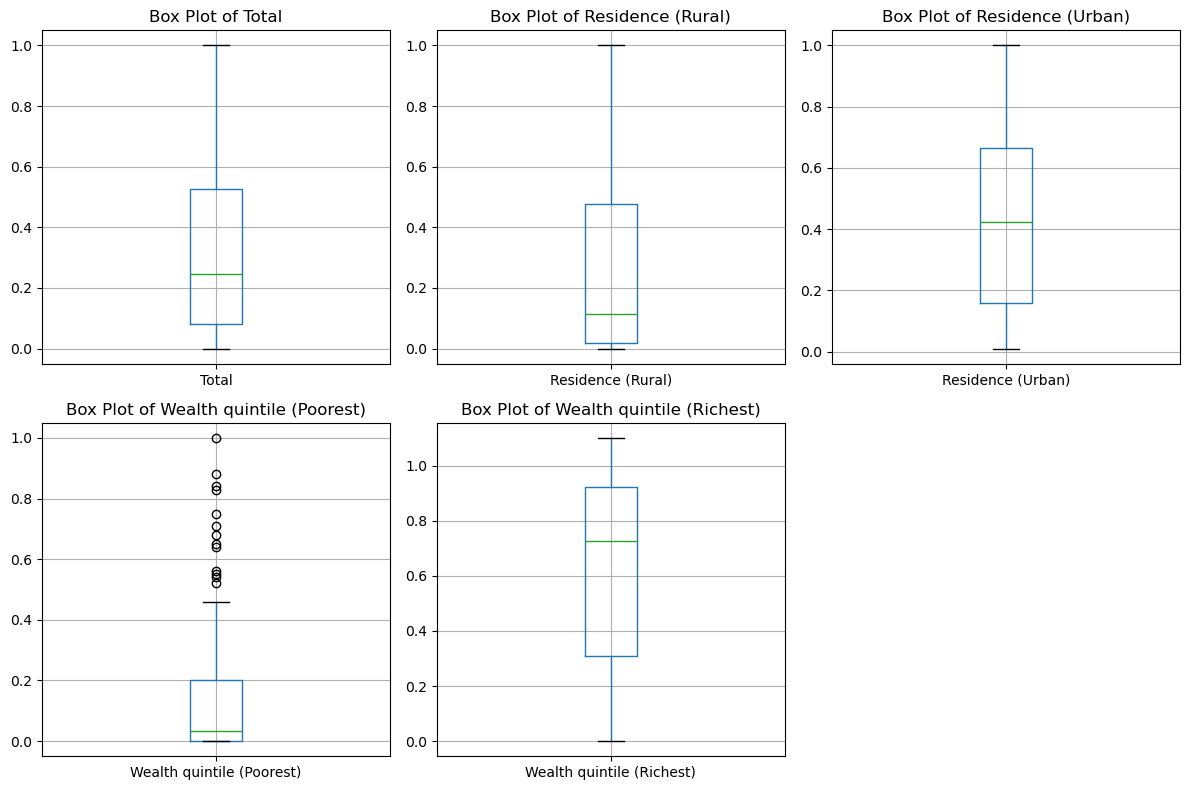

In [14]:
import matplotlib.pyplot as plt

# Plotting box plots for each percentage column individually
plt.figure(figsize=(12, 8))

# Box plot for 'Total'
plt.subplot(2, 3, 1)  
df.boxplot(column='Total')
plt.title('Box Plot of Total')

# Box plot for 'Residence (Rural)'
plt.subplot(2, 3, 2)  
df.boxplot(column='Residence (Rural)')
plt.title('Box Plot of Residence (Rural)')

# Box plot for 'Residence (Urban)'
plt.subplot(2, 3, 3)  
df.boxplot(column='Residence (Urban)')
plt.title('Box Plot of Residence (Urban)')

# Box plot for 'Wealth quintile (Poorest)'
plt.subplot(2, 3, 4)  
df.boxplot(column='Wealth quintile (Poorest)')
plt.title('Box Plot of Wealth quintile (Poorest)')

# Box plot for 'Wealth quintile (Richest)'
plt.subplot(2, 3, 5) 
df.boxplot(column='Wealth quintile (Richest)')
plt.title('Box Plot of Wealth quintile (Richest)')

plt.tight_layout() 
plt.show()

In [15]:
# Calculate the range
df.max()

ISO3                                              ZWE
Countries and areas                          Zimbabwe
Region                                            SSA
Sub-region                                        WCA
Income Group                 Upper middle income (UM)
Total                                             1.0
Residence (Rural)                                 1.0
Residence (Urban)                                 1.0
Wealth quintile (Poorest)                         1.0
Wealth quintile (Richest)                         1.1
Time period                                      2019
dtype: object

In [16]:
df.min()

ISO3                                     AGO
Countries and areas                  Algeria
Region                                   EAP
Sub-region                               EAP
Income Group                 High income (H)
Total                                    0.0
Residence (Rural)                        0.0
Residence (Urban)                       0.01
Wealth quintile (Poorest)                0.0
Wealth quintile (Richest)                0.0
Time period                             2010
dtype: object

In [17]:
# Filter rows where any of the specified columns have values greater than 1.0
over_1_rows = df[(df['Total'] > 1.0) | 
                 (df['Residence (Rural)'] > 1.0) | 
                 (df['Residence (Urban)'] > 1.0) | 
                 (df['Wealth quintile (Poorest)'] > 1.0) | 
                 (df['Wealth quintile (Richest)'] > 1.0)]

# Display the rows
print(over_1_rows)

   ISO3 Countries and areas Region Sub-region              Income Group  \
59  RUS  Russian Federation    ECA       EECA  Upper middle income (UM)   

    Total  Residence (Rural)  Residence (Urban)  Wealth quintile (Poorest)  \
59   0.86               0.79               0.94                       0.88   

    Wealth quintile (Richest) Time period  
59                        1.1        2018  


This row contains and irregular value, as the percentage needs to be within 0-100 and initially all the percentage values are converted and are now within 0-1. Hence we will drop this.

In [18]:
# Drop these rows from the original DataFrame
df = df.drop(over_1_rows.index)

# Reset the index for a clean DataFrame
df.reset_index(drop=True, inplace=True)

In [19]:
df.max()

ISO3                                              ZWE
Countries and areas                          Zimbabwe
Region                                            SSA
Sub-region                                        WCA
Income Group                 Upper middle income (UM)
Total                                             1.0
Residence (Rural)                                 1.0
Residence (Urban)                                 1.0
Wealth quintile (Poorest)                         1.0
Wealth quintile (Richest)                         1.0
Time period                                      2019
dtype: object

##### 4. Removing duplicate rows

In [20]:
import pandas as pd

# Check for duplicates across all columns
duplicates_all = df[df.duplicated()]

# Display the duplicate rows
print("Duplicates across all columns:")
print(duplicates_all)

Duplicates across all columns:
   ISO3 Countries and areas Region Sub-region              Income Group  \
28  GTM           Guatemala    LAC        LAC  Upper middle income (UM)   
67  TGO                Togo    SSA        WCA            Low income (L)   
68  TGO                Togo    SSA        WCA            Low income (L)   

    Total  Residence (Rural)  Residence (Urban)  Wealth quintile (Poorest)  \
28   0.10               0.03               0.20                        0.0   
67   0.24               0.08               0.49                        0.0   
68   0.24               0.08               0.49                        0.0   

    Wealth quintile (Richest) Time period  
28                       0.49   2014-2015  
67                       0.78        2017  
68                       0.78        2017  


In [21]:
df = df.drop_duplicates()

In [22]:
df

,ISO3,Countries and areas,Region,Sub-region,Income Group,Total,Residence (Rural),Residence (Urban),Wealth quintile (Poorest),Wealth quintile (Richest),Time period
0,DZA,Algeria,MENA,MENA,Upper middle income (UM),0.25,0.10,0.33,0.01,0.78,2018-2019
1,AGO,Angola,SSA,ESA,Lower middle income (LM),0.19,0.02,0.27,0.00,0.62,2015-2016
2,ARM,Armenia,ECA,EECA,Upper middle income (UM),0.81,0.71,0.89,0.44,0.99,2015-2016
3,BGD,Bangladesh,SA,SA,Lower middle income (LM),0.34,0.31,0.48,0.08,0.73,2019
4,BRB,Barbados,LAC,LAC,High income (H),0.68,0.66,0.69,0.20,1.00,2012
...,...,...,...,...,...,...,...,...,...,...,...
74,UGA,Uganda,SSA,ESA,Low income (L),0.00,0.00,0.01,0.00,0.01,2015
75,UZB,Uzbekistan,ECA,EECA,Lower middle income (LM),0.18,0.14,0.31,0.01,0.70,2017
76,VNM,Viet Nam,EAP,EAP,Lower middle income (LMM),0.45,0.17,0.62,0.11,0.82,2012
77,ZMB,Zambia,SSA,ESA,Lower middle income (LM),0.08,0.02,0.16,0.00,0.31,2018-2019


In [23]:
df.shape

(76, 11)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 76 entries, 0 to 78
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ISO3                       76 non-null     object 
 1   Countries and areas        76 non-null     object 
 2   Region                     76 non-null     object 
 3   Sub-region                 76 non-null     object 
 4   Income Group               76 non-null     object 
 5   Total                      76 non-null     float64
 6   Residence (Rural)          76 non-null     float64
 7   Residence (Urban)          76 non-null     float64
 8   Wealth quintile (Poorest)  76 non-null     float64
 9   Wealth quintile (Richest)  76 non-null     float64
 10  Time period                76 non-null     object 
dtypes: float64(5), object(6)
memory usage: 7.1+ KB


In [25]:
df.columns.to_list()

['ISO3',
 'Countries and areas',
 'Region',
 'Sub-region',
 'Income Group',
 'Total',
 'Residence (Rural)',
 'Residence (Urban)',
 'Wealth quintile (Poorest)',
 'Wealth quintile (Richest)',
 'Time period']

In [26]:
df.isna().sum()

ISO3                         0
Countries and areas          0
Region                       0
Sub-region                   0
Income Group                 0
Total                        0
Residence (Rural)            0
Residence (Urban)            0
Wealth quintile (Poorest)    0
Wealth quintile (Richest)    0
Time period                  0
dtype: int64

In [27]:
output_path = "s4016395-cleaned-A1data.csv"
df.to_csv(output_path, sep=',', index=False)

# Task 2: Data Exploration

## Task 2.1 

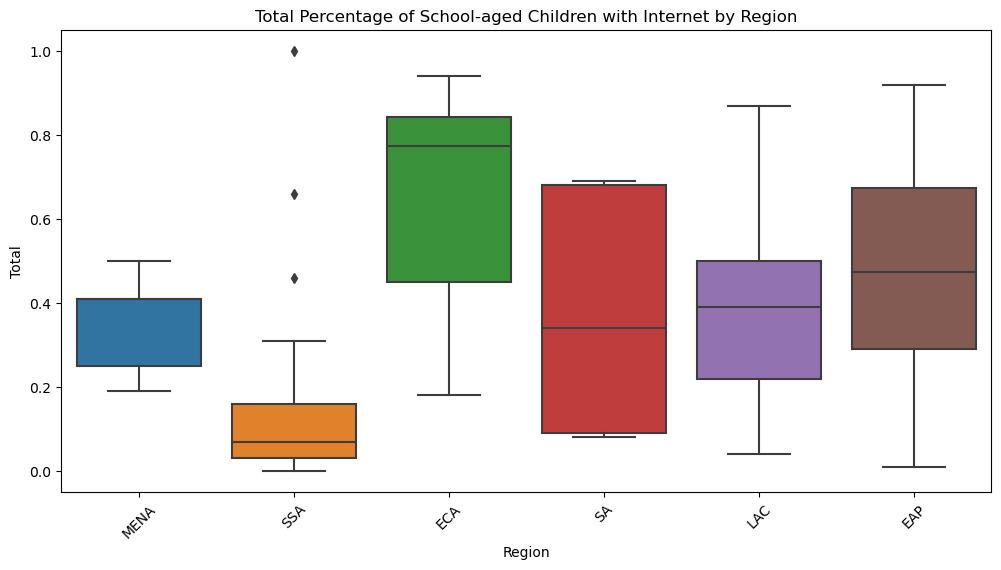

Median percentage by region:
 Region
EAP     0.475
ECA     0.775
LAC     0.390
MENA    0.410
SA      0.340
SSA     0.070
Name: Total, dtype: float64


In [28]:
# Loading necessary libraries for data visualisation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the cleaned data
data_cleaned = pd.read_csv("s4016395-cleaned-A1data.csv")

# Boxplot of Total percentage by Region
plt.figure(figsize=(12, 6))
sns.boxplot(x='Region', y='Total', data=data_cleaned)
plt.title('Total Percentage of School-aged Children with Internet by Region')
plt.xticks(rotation=45)
plt.show()

# Calculate the median for each region
median_by_region = data_cleaned.groupby('Region')['Total'].median()
print("Median percentage by region:\n", median_by_region)

## Task 2.2 

In [29]:
# Mean percentage for Wealth quintile Poorest and Richest
mean_poorest = data_cleaned['Wealth quintile (Poorest)'].mean()
mean_richest = data_cleaned['Wealth quintile (Richest)'].mean()

print(f"Mean percentage for Poorest wealth quintile: {mean_poorest:.2f}")
print(f"Mean percentage for Richest wealth quintile: {mean_richest:.2f}")

# Top 10 countries for Poorest and Richest wealth quintiles
top_10_poorest = data_cleaned.nlargest(10, 'Wealth quintile (Poorest)')
top_10_richest = data_cleaned.nlargest(10, 'Wealth quintile (Richest)')

print("Top 10 countries for Poorest wealth quintile:\n", top_10_poorest[['Countries and areas', 'Wealth quintile (Poorest)']])
print("Top 10 countries for Richest wealth quintile:\n", top_10_richest[['Countries and areas', 'Wealth quintile (Richest)']])

Mean percentage for Poorest wealth quintile: 0.17
Mean percentage for Richest wealth quintile: 0.60
Top 10 countries for Poorest wealth quintile:
    Countries and areas  Wealth quintile (Poorest)
58             Somalia                       1.00
8               Brazil                       0.84
66               Tonga                       0.83
14               Chile                       0.75
60           Sri Lanka                       0.71
64     North Macedonia                       0.68
56              Serbia                       0.65
33               Japan                       0.64
37          Kyrgyzstan                       0.56
45          Montenegro                       0.55
Top 10 countries for Richest wealth quintile:
    Countries and areas  Wealth quintile (Richest)
4             Barbados                       1.00
9             Bulgaria                       1.00
56              Serbia                       1.00
58             Somalia                       1.00
64    

## Task 2.3 

In [30]:
# Filter data for the Lower Middle Income Group
lm_data = data_cleaned[data_cleaned['Income Group'] == 'Lower middle income (LM)']

# Statistical measures for Rural vs Urban
# Calculating mean
mean_rural = lm_data['Residence (Rural)'].mean()
mean_urban = lm_data['Residence (Urban)'].mean()
# Calculating Median
median_rural = lm_data['Residence (Rural)'].median()
median_urban = lm_data['Residence (Urban)'].median()
# Calculating standard deviation
std_rural = lm_data['Residence (Rural)'].std()
std_urban = lm_data['Residence (Urban)'].std()

print(f"Rural - Mean: {mean_rural:.2f}, Median: {median_rural:.2f}, Std Dev: {std_rural:.2f}")
print(f"Urban - Mean: {mean_urban:.2f}, Median: {median_urban:.2f}, Std Dev: {std_urban:.2f}")

Rural - Mean: 0.12, Median: 0.04, Std Dev: 0.16
Urban - Mean: 0.28, Median: 0.23, Std Dev: 0.21
